In [1]:
import pandas as pd
import keras
import os
import numpy as np
from sklearn.metrics import log_loss
from keras import Model,Sequential
from keras.layers import *
from keras.optimizers import *
from sklearn.model_selection import train_test_split
import cv2
from tqdm.notebook import tqdm
import glob
import json
import matplotlib.pyplot as plt
from keras.callbacks import LearningRateScheduler
import keras.backend as K
import gc
from sklearn.metrics import precision_score,accuracy_score, log_loss,roc_curve, auc, f1_score, precision_recall_curve, recall_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load 256 dataset
image_dir = '/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/cropped_images'

json_file = '/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/deepfake-detection-challenge/train_sample_videos/metadata.json'

# Load labels from JSON file
with open(json_file, 'r') as f:
    labels = json.load(f)

# Preprocess images, labels, and video names
images = []
image_labels = []
video_names = []

for image_name in os.listdir(image_dir):
    if image_name.endswith('.jpg'):
        # Load and resize image
        image_path = os.path.join(image_dir, image_name)
        image = cv2.imread(image_path)
        image = cv2.resize(image, (256, 256)) # Normalize image
        # image = image / 255.0

        # Extract video name from image name
        video_name = image_name.split('_')[0] + '.mp4'

        if video_name in labels:
            label = 1 if labels[video_name]['label'] == 'FAKE' else 0
            images.append(image)
            video_names.append(video_name)
            image_labels.append(label)
        else:
            #print(f"Warning: {video_name} not found in metadata.")
            continue

# Convert lists to numpy arrays
X = np.array(images)
y = np.array(image_labels)
video_names = np.array(video_names)
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Video names shape: {video_names.shape}')
#Split data into training and test sets
X_train, test_X, y_train, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'test_X shape: {test_X.shape}')
print(f'test_y shape: {test_y.shape}')

X shape: (2517, 256, 256, 3)
y shape: (2517,)
Video names shape: (2517,)
X_train shape: (2013, 256, 256, 3)
y_train shape: (2013,)
test_X shape: (504, 256, 256, 3)
test_y shape: (504,)


In [ ]:
#define model
def InceptionLayer(a, b, c, d):
    def func(x):
        x1 = Conv2D(a, (1, 1), padding='same', activation='elu')(x)

        x2 = Conv2D(b, (1, 1), padding='same', activation='elu')(x)
        x2 = Conv2D(b, (3, 3), padding='same', activation='elu')(x2)

        x3 = Conv2D(c, (1, 1), padding='same', activation='elu')(x)
        x3 = Conv2D(c, (3, 3), dilation_rate = 2, strides = 1, padding='same', activation='elu')(x3)

        x4 = Conv2D(d, (1, 1), padding='same', activation='elu')(x)
        x4 = Conv2D(d, (3, 3), dilation_rate = 3, strides = 1, padding='same', activation='elu')(x4)
        y = Concatenate(axis = -1)([x1, x2, x3, x4])

        return y
    return func

def define_model(shape=(256,256,3)):
    x = Input(shape = shape)

    x1 = InceptionLayer(1, 4, 4, 2)(x)
    x1 = BatchNormalization()(x1)
    x1 = MaxPooling2D(pool_size=(2, 2), padding='same')(x1)

    x2 = InceptionLayer(2, 4, 4, 2)(x1)
    x2 = BatchNormalization()(x2)
    x2 = MaxPooling2D(pool_size=(2, 2), padding='same')(x2)

    x3 = Conv2D(16, (5, 5), padding='same', activation = 'elu')(x2)
    x3 = BatchNormalization()(x3)
    x3 = MaxPooling2D(pool_size=(2, 2), padding='same')(x3)

    x4 = Conv2D(16, (5, 5), padding='same', activation = 'elu')(x3)
    x4 = BatchNormalization()(x4)
    if shape==(256,256,3):
        x4 = MaxPooling2D(pool_size=(4, 4), padding='same')(x4)
    else:
        x4 = MaxPooling2D(pool_size=(2, 2), padding='same')(x4)
    y = Flatten()(x4)
    y = Dropout(0.5)(y)
    y = Dense(16)(y)
    y = LeakyReLU(negative_slope=0.1)(y)
    y = Dropout(0.5)(y)
    y = Dense(1, activation = 'sigmoid')(y)
    model=Model(inputs = x, outputs = y)
    model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=1e-4), metrics=['accuracy'])#add accuracy
    #model.summary()
    return model
df_model=define_model()
df_model.load_weights('/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/pretrain/MesoInception_DF.h5')
f2f_model=define_model()
f2f_model.load_weights('/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/pretrain/MesoInception_F2F.h5')

In [ ]:
# Split data into one training and validation sets
X_train1, val_X, y_train1, val_y = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f'X_train1 shape: {X_train1.shape}')
print(f'y_train1 shape: {y_train1.shape}')
print(f'val_X shape: {val_X.shape}')
print(f'val_y shape: {val_y.shape}')

X_train1 shape: (805, 256, 256, 3)
y_train1 shape: (805,)
val_X shape: (202, 256, 256, 3)
val_y shape: (202,)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_33 (Conv2D)        │ (None, 256, 256, 4)    │             16 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_35 (Conv2D)        │ (None, 256, 256, 4)    │             16 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_37 (Conv2D)        │ (None, 256, 256, 2)    │              8 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_32 (Conv2D)        │ (None, 256, 256, 1)    │              4 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_34 (Conv2D)        │ (None, 256, 256, 4)    │            148 │ conv2d_33[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_36 (Conv2D)        │ (None, 256, 256, 4)    │            148 │ conv2d_35[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_38 (Conv2D)        │ (None, 256, 256, 2)    │             38 │ conv2d_37[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_4             │ (None, 256, 256, 11)   │              0 │ conv2d_32[0][0],       │
│ (Concatenate)             │                        │                │ conv2d_34[0][0],       │
│                           │                        │                │ conv2d_36[0][0],       │
│                           │                        │                │ conv2d_38[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_8     │ (None, 256, 256, 11)   │             44 │ concatenate_4[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_8           │ (None, 128, 128, 11)   │              0 │ batch_normalization_8… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_40 (Conv2D)        │ (None, 128, 128, 4)    │             48 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_42 (Conv2D)        │ (None, 128, 128, 4)    │             48 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_44 (Conv2D)        │ (None, 128, 128, 2)    │             24 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_39 (Conv2D)        │ (None, 128, 128, 2)    │             24 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_41 (Conv2D)        │ (None, 128, 128, 4)    │            148 │ conv2d_40[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_43 (Conv2D)   

 Total params: 28,725 (112.21 KB)

 Trainable params: 28,615 (111.78 KB)

 Non-trainable params: 110 (440.00 B)

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Pretrained fold 0 DF model - Validation loss: 5.051068864522127, Validation accuracy: 0.6831683168316832
Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 162s 6s/step - accuracy: 0.6604 - loss: 2.7316 - val_accuracy: 0.2772 - val_loss: 42.4733 - learning_rate: 1.0000e-04
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 204s 6s/step - accuracy: 0.6826 - loss: 1.3603 - val_accuracy: 0.2772 - val_loss: 27.9669 - learning_rate: 5.0000e-05
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 151s 6s/step - accuracy: 0.6644 - loss: 1.0717 - val_accuracy: 0.2772 - val_loss: 21.2872 - learning_rate: 1.0000e-06
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 161s 6s/step - accuracy: 0.6599 - loss: 1.0804 - val_accuracy: 0.2772 - val_loss: 16.8913 - learning_rate: 5.0000e-07
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 192s 6s/step - accuracy: 0.6895 - loss: 1.0014 - val_accuracy: 0.2772 - val_loss: 13.4836 - learning_rate: 1.0000e-08


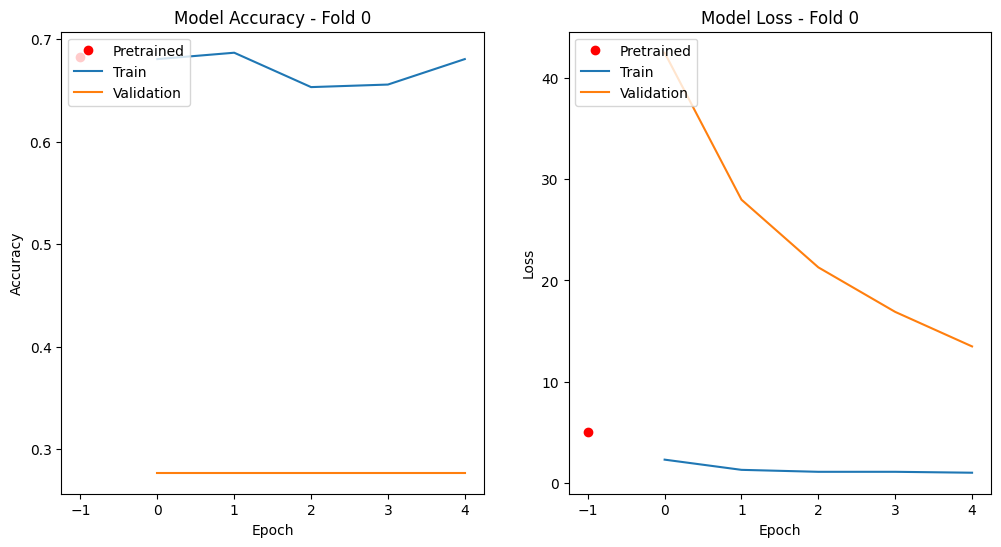

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
fold 0 model loss: 11.183688427126986
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Pretrained fold 0 F2F model - Validation loss: 4.4565388794716005, Validation accuracy: 0.693069306930693
Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 161s 6s/step - accuracy: 0.6150 - loss: 1.4782 - val_accuracy: 0.6980 - val_loss: 1.5182 - learning_rate: 1.0000e-04
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 202s 6s/step - accuracy: 0.6491 - loss: 1.0072 - val_accuracy: 0.7178 - val_loss: 1.3436 - learning_rate: 5.0000e-05
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 200s 6s/step - accuracy: 0.6339 - loss: 0.8571 - val_accuracy: 0.7228 - val_loss: 1.6543 - learning_rate: 1.0000e-06
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 148s 6s/step - accuracy: 0.6396 - loss: 0.8272 - val_accuracy: 0.7228 - val_loss: 2.1685 - learning_rate: 5.0000e-07
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 202s 6s/step - accuracy: 0.6481 - loss: 0.8756 - val_accuracy: 0.7228 - val_loss: 2.7387 - learning_rate: 1.0000e-08


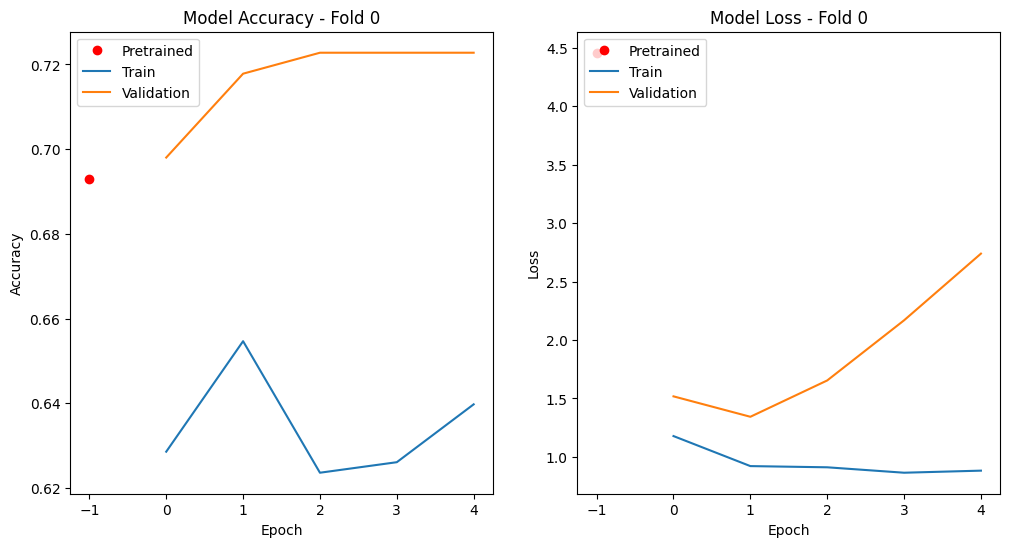

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step
fold 0 model loss: 2.6685079699785064
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
Model 0 - Test loss: 3.1653989096819575, Test accuracy: 0.6746031746031746
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
Model 1 - Test loss: 3.1653989096819575, Test accuracy: 0.6746031746031746
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step
Model 2 - Test loss: 10.490961177370865, Test accuracy: 0.3253968253968254
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
Model 3 - Test loss: 10.490961177370865, Test accuracy: 0.3253968253968254


In [ ]:
#train add inference and learning curve & pretrained model
# Learning rate schedule
lrs=[]
def schedule(epoch):
    return lrs[epoch]

LOAD_PRETRAIN = True
INFERENCE = True
kfolds = 1
df_models = []
f2f_models = []
losses = []
accuracies = []  # To store accuracy values

def evaluate_model(model, test_X, test_y):
    pred = model.predict(test_X)
    # pred is a (num_samples, 1) array, so squeeze it to (num_samples,)
    pred = pred.squeeze()
    loss = log_loss(test_y, pred)
    # Since test_y and pred are both (num_samples,) now, we can use accuracy_score directly
    acc = accuracy_score(test_y, (pred > 0.5).astype(int))
    return loss, acc

# Function to plot learning curves including pretrained metrics
def plot_learning_curves(history, fold_index, pretrain_acc=None, pretrain_loss=None):
    plt.figure(figsize=(12, 6))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    if pretrain_acc is not None:
        plt.plot([-1], [pretrain_acc], 'ro', label='Pretrained')  # Pretrained accuracy as a point
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'Model Accuracy - Fold {fold_index}')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    if pretrain_loss is not None:
        plt.plot([-1], [pretrain_loss], 'ro', label='Pretrained')  # Pretrained loss as a point
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'Model Loss - Fold {fold_index}')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.show()

if LOAD_PRETRAIN:
    lrs = [1e-4, 5e-5, 1e-6, 5e-7, 1e-8]
    i = 0
    while len(df_models) < kfolds:
        model = define_model((256, 256, 3))
        if i == 0:
            model.summary()
        model.load_weights('/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/pretrain/MesoInception_DF.h5')
        df_models.append(model)
        # Evaluate pretrained model
        if INFERENCE:
            pretrain_loss, pretrain_acc = evaluate_model(model, val_X, val_y)
            print(f'Pretrained fold {i} DF model - Validation loss: {pretrain_loss}, Validation accuracy: {pretrain_acc}')

        # Continue training and capture the history
        history = model.fit([X_train1], [y_train1], epochs=5, validation_data=(val_X, val_y), callbacks=[LearningRateScheduler(schedule)])

        # Plot learning curves including pretrained metrics
        plot_learning_curves(history, i, pretrain_acc, pretrain_loss)

        pred = model.predict([val_X])
        loss = log_loss(val_y, pred)
        losses.append(loss)
        print('fold ' + str(i) + ' model loss: ' + str(loss))
        df_models.append(model)
        K.clear_session()
        del model
        gc.collect()
        i += 1

    i = 0
    while len(f2f_models) < kfolds:
        model = define_model((256, 256, 3))
        model.load_weights('/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/pretrain/MesoInception_F2F.h5')
        f2f_models.append(model)
        # Evaluate pretrained model
        if INFERENCE:
            pretrain_loss, pretrain_acc = evaluate_model(model, val_X, val_y)
            print(f'Pretrained fold {i} F2F model - Validation loss: {pretrain_loss}, Validation accuracy: {pretrain_acc}')

        # Continue training and capture the history
        history = model.fit([X_train1], [y_train1], epochs=5, validation_data=(val_X, val_y), callbacks=[LearningRateScheduler(schedule)])

        # Plot learning curves including pretrained metrics
        plot_learning_curves(history, i, pretrain_acc, pretrain_loss)

        pred = model.predict([val_X])
        loss = log_loss(val_y, pred)
        losses.append(loss)
        print('fold ' + str(i) + ' model loss: ' + str(loss))
        f2f_models.append(model)
        K.clear_session()
        del model
        gc.collect()
        i += 1

    models = f2f_models + df_models

    # Inference part
    if INFERENCE:
        for idx, model in enumerate(models):
            loss, acc = evaluate_model(model, test_X, test_y)
            print(f'Model {idx} - Test loss: {loss}, Test accuracy: {acc}')
            accuracies.append(acc)

# else:
#     models = []
#     i = 0
#     while len(models) < kfolds:
#         model = define_model((256, 256, 3))
#         if i == 0:
#             model.summary()
#         history = model.fit([X_train1], [y_train1], epochs=5, validation_data=(val_X, val_y), callbacks=[LearningRateScheduler(schedule)])

#         # Plot learning curves without pretrained metrics
#         plot_learning_curves(history, i)

#         pred = model.predict([val_X])
#         loss = log_loss(val_y, pred)
#         losses.append(loss)
#         print('fold ' + str(i) + ' model loss: ' + str(loss))
#         if loss < 0.68:
#             models.append(model)
#         else:
#             print('loss too bad, retrain!')
#         K.clear_session()
#         del model
#         gc.collect()
#         i += 1

#     # Inference part
#     if INFERENCE:
#         for idx, model in enumerate(models):
#             loss, acc = evaluate_model(model, test_X, test_y)
#             print(f'Model {idx} - Test loss: {loss}, Test accuracy: {acc}')
#             accuracies.append(acc)


In [ ]:
def prediction_pipline(X,two_times=False):
    preds=[]
    for model in tqdm(models):
        pred=model.predict([X])
        preds.append(pred)
    preds=sum(preds)/len(preds)
    if two_times:
        return larger_range(preds,2)
    else:
        return preds
def larger_range(model_pred,time):
    return (((model_pred-0.5)*time)+0.5)

In [ ]:
model_pred=prediction_pipline(test_X)
# loss
random_pred=np.random.random(len(test_X))
print('random loss: ' + str(log_loss(test_y,random_pred.clip(0.35,0.65))))
allone_pred=np.array([1 for _ in range(len(test_X))])
print('1 loss: ' + str(log_loss(test_y,allone_pred)))
allzero_pred=np.array([0 for _ in range(len(test_X))])
print('0 loss: ' + str(log_loss(test_y,allzero_pred)))
allpoint5_pred=np.array([0.5 for _ in range(len(test_X))])
print('0.5 loss: ' + str(log_loss(test_y,allpoint5_pred)))

random loss: 0.715548033996707
1 loss: 11.728490388522246
0 loss: 24.3151630005949
0.5 loss: 0.6931471805599454


8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
Accuracy: 0.6746031746031746
F1 Score: 0.8056872037914692
Precision: 0.6746031746031746
Recall: 1.0


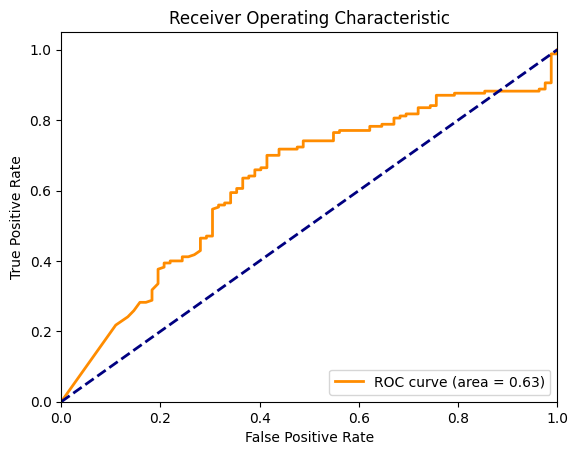

Simple Averaging Loss: 0.6320546433679519


In [ ]:
#evaluation for pretrained model
best_model_index=losses.index(min(losses))
best_model=models[best_model_index]
best_model_pred=best_model.predict([test_X])

y_pred = (best_model_pred > 0.5).astype(int)
# acc
accuracy = accuracy_score(test_y, y_pred)
print('Accuracy:', accuracy)
# f1
f1 = f1_score(test_y, y_pred)
print('F1 Score:', f1)
# precision
precision = precision_score(test_y, y_pred)
print('Precision:', precision)
# recall
recall = recall_score(test_y, y_pred)
print('Recall:', recall)
# ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(test_y, best_model_pred)
roc_auc = auc(fpr, tpr)
# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
#Model loss
print('Simple Averaging Loss: '+str(log_loss(test_y,model_pred.clip(0.35,0.65))))
# print('Two Times Larger Range(Averaging) Loss: '+str(log_loss(test_y,larger_range(model_pred,2).clip(0.35,0.65))))
# print('Best Single Model Loss: '+str(log_loss(test_y,best_model_pred.clip(0.35,0.65))))
# print('Two Times Larger Range(Single Model) Loss: '+str(log_loss(test_y,larger_range(best_model_pred,2).clip(0.35,0.65))))
# if log_loss(test_y,model_pred.clip(0.35,0.65))<log_loss(test_y,larger_range(model_pred,2).clip(0.35,0.65)):
#     two_times=False
#     print('simple averaging is better')
# else:
#     two_times=True
#     print('two times larger range is better')
# two_times=False #This is not a bug. I did this intentionally because the model can't get most of the private validation set right(based on LB)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 4)    │             16 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 256, 256, 4)    │             16 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 256, 256, 2)    │              8 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 1)    │              4 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 256, 256, 4)    │            148 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 256, 256, 4)    │            148 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 256, 256, 2)    │             38 │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 256, 256, 11)   │              0 │ conv2d[0][0],          │
│                           │                        │                │ conv2d_2[0][0],        │
│                           │                        │                │ conv2d_4[0][0],        │
│                           │                        │                │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 11)   │             44 │ concatenate[0][0]      │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 11)   │              0 │ batch_normalization[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 128, 128, 4)    │             48 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 128, 128, 4)    │             48 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 128, 128, 2)    │             24 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 128, 128, 2)    │             24 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 128, 128, 4)    │            148 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 128, 128, 4)    │            148 │ conv2d_10[0][0]        │
├──────────────────────

 Total params: 28,725 (112.21 KB)

 Trainable params: 28,615 (111.78 KB)

 Non-trainable params: 110 (440.00 B)

Epoch 1/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 162s 6s/step - accuracy: 0.5750 - loss: 2.0256 - val_accuracy: 0.7228 - val_loss: 7.4193 - learning_rate: 0.0500
Epoch 2/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 198s 6s/step - accuracy: 0.6634 - loss: 0.6725 - val_accuracy: 0.7228 - val_loss: 1.3032 - learning_rate: 0.0010
Epoch 3/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 199s 6s/step - accuracy: 0.6877 - loss: 0.6660 - val_accuracy: 0.7228 - val_loss: 0.7537 - learning_rate: 5.0000e-04
Epoch 4/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 202s 6s/step - accuracy: 0.6696 - loss: 0.6755 - val_accuracy: 0.7178 - val_loss: 0.6764 - learning_rate: 1.0000e-04
Epoch 5/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 150s 6s/step - accuracy: 0.6717 - loss: 0.6449 - val_accuracy: 0.7178 - val_loss: 0.6476 - learning_rate: 5.0000e-05
Epoch 6/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 213s 6s/step - accuracy: 0.6705 - loss: 0.6654 - val_accuracy: 0.7178 - val_loss: 0.6215 - learning_rate: 1.0000e-06
Epoch 7/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 148s 6s/step - accuracy: 0.6714 - loss: 0.6575 

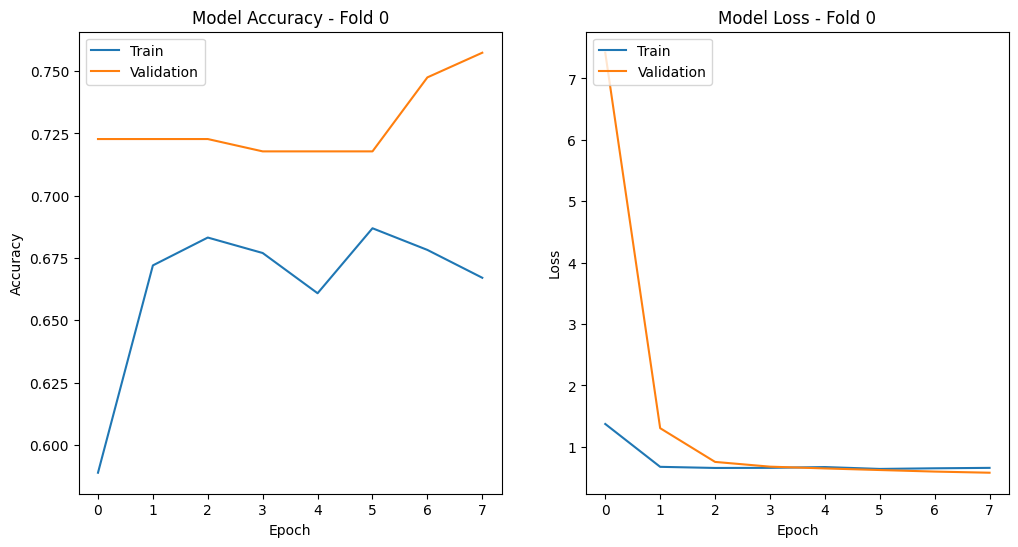

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
fold 0 model loss: 0.5776087225920088
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step
Model 0 - Test loss: 0.61625879041613, Test accuracy: 0.7222222222222222


In [ ]:
# LOAD_PRETRAIN = False
# lrs = [5e-2, 1e-3, 5e-4, 1e-4, 5e-5, 1e-6, 5e-7,1e-8]
# if not LOAD_PRETRAIN:
#   models = []
#   i = 0
#   while len(models) < kfolds:
#     model = define_model((256, 256, 3))
#     if i == 0:
#       model.summary()
#       history = model.fit([X_train1], [y_train1], epochs=8, validation_data=(val_X, val_y), callbacks=[LearningRateScheduler(schedule)])
#       # Plot learning curves
#       plot_learning_curves(history, i)
#       pred = model.predict([val_X])
#       loss = log_loss(val_y, pred)
#       losses.append(loss)
#       print('fold ' + str(i) + ' model loss: ' + str(loss))
#       if loss < 0.68:
#         models.append(model)
#       else: print('loss too bad!')
#       K.clear_session()
#       del model
#       gc.collect()
#       i += 1
#   # Inference part
#   if INFERENCE:
#     for idx, model in enumerate(models):
#       loss, acc = evaluate_model(model, test_X, test_y)
#       print(f'Model {idx} - Test loss: {loss}, Test accuracy: {acc}')
#       accuracies.append(acc)

In [ ]:
# # evaluation train from scratch
# best_model_index=losses.index(min(losses))
# best_model=models[best_model_index]
# best_model_pred=best_model.predict([test_X])

# y_pred = (best_model_pred > 0.5).astype(int)
# # acc
# accuracy = accuracy_score(test_y, y_pred)
# print('Accuracy:', accuracy)
# # f1
# f1 = f1_score(test_y, y_pred)
# print('F1 Score:', f1)
# # precision
# precision = precision_score(test_y, y_pred)
# print('Precision:', precision)
# # recall
# recall = recall_score(test_y, y_pred)
# print('Recall:', recall)
# # ROC curve and ROC area
# fpr, tpr, thresholds = roc_curve(test_y, best_model_pred)
# roc_auc = auc(fpr, tpr)
# # Plot ROC curve
# plt.figure()
# plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic')
# plt.legend(loc="lower right")
# plt.show()
# #Model loss
# print('Simple Averaging Loss: '+str(log_loss(test_y,model_pred.clip(0.35,0.65))))